# Random Forest — Portfolio Backtest & P&L Analysis

## Objective
Simulate what would happen if an investor followed the Random Forest model's weekly stock ranking recommendations with $10,000 starting capital.

## How It Works — Week by Week
1. **Monday (start of week):** Model predicts P(Up) for each of the 15 stocks using last week's features
2. **Monday:** Allocate capital — higher ranked stocks get more weight
3. **Friday (end of week):** Compare allocated weights against actual returns
4. **Record:** Profit or loss for that week, update portfolio value
5. **Repeat** for every week in the test period (2024–present)

## Benchmarks
- **Equal Weight:** 1/15 = 6.67% in each stock every week (no prediction needed)
- **S&P 500:** Broad market index
- **Nasdaq:** Tech-heavy index
- **Oracle (perfect):** What if we always knew the best stock each week?

## 1. Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print('Imports ready.')

Imports ready.


## 2. Configuration

In [10]:
INITIAL_CAPITAL = 10_000
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'GS', 'JNJ', 'PFE', 'XOM', 'CVX', 'WMT', 'BA']
OUT_DIR = '../data/results'
os.makedirs(OUT_DIR, exist_ok=True)

FILES = {
    'AAPL':  '../data/Apple.csv',
    'MSFT':  '../data/MSFT.csv',
    'GOOGL': '../data/google.csv',
    'AMZN':  '../data/Amazon.csv',
    'NVDA':  '../data/NVIDIA.csv',
    'META':  '../data/META.csv',
    'TSLA':  '../data/TSLA.csv',
    'JPM':   '../data/JPM.csv',
    'GS':    '../data/GSach.csv',
    'JNJ':   '../data/JNJ.csv',
    'PFE':   '../data/PFE.csv',
    'XOM':   '../data/XOM.csv',
    'CVX':   '../data/CVX.csv',
    'WMT':   '../data/WMT.csv',
    'BA':    '../data/BA.csv',
}

COLORS = {
    'AAPL': '#1f77b4', 'MSFT': '#ff7f0e', 'GOOGL': '#2ca02c',
    'AMZN': '#d62728', 'NVDA': '#9467bd', 'META': '#8c564b',
    'TSLA': '#e377c2', 'JPM': '#7f7f7f', 'GS': '#bcbd22',
    'JNJ': '#17becf', 'PFE': '#aec7e8', 'XOM': '#ffbb78',
    'CVX': '#98df8a', 'WMT': '#ff9896', 'BA': '#c5b0d5'
}

print(f'Starting capital: ${INITIAL_CAPITAL:,}')
print(f'Stocks: {len(TICKERS)}')

Starting capital: $10,000
Stocks: 15


## 3. Load Actual Weekly Returns

In [11]:
def load_file(path):
    try:
        df = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding='latin1')
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    df['Close'] = pd.to_numeric(df['Close'], errors='coerce')
    return df.sort_values('Date').dropna(subset=['Close'])

frames = []
for ticker, path in FILES.items():
    df = load_file(path).set_index('Date')
    w = pd.DataFrame()
    w['Close'] = df['Close'].resample('W-FRI').last()
    w['Weekly_Return'] = w['Close'].pct_change()  # decimal
    w['Ticker'] = ticker
    w = w.dropna().reset_index()
    frames.append(w)

all_weekly = pd.concat(frames).sort_values(['Date', 'Ticker']).reset_index(drop=True)
test_data  = all_weekly[all_weekly['Date'] >= '2024-01-01'].copy()

actual_returns = test_data.pivot_table(index='Date', columns='Ticker', values='Weekly_Return').sort_index()
# Keep only tickers present in predictions
actual_returns = actual_returns[[t for t in TICKERS if t in actual_returns.columns]]
weeks = actual_returns.index

print(f'Test period: {weeks[0].date()} to {weeks[-1].date()} ({len(weeks)} weeks)')
print(f'Stocks: {list(actual_returns.columns)}')

Test period: 2024-01-05 to 2026-02-27 (113 weeks)
Stocks: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'GS', 'JNJ', 'PFE', 'XOM', 'CVX', 'WMT', 'BA']


## 4. Load RF Predictions & Build Weekly Allocation Table

For each week, the model outputs P(Up) for each stock. We rank stocks and convert ranks to portfolio weights.

In [12]:
# Load RF predictions
rf_raw = pd.read_csv(f'{OUT_DIR}/rf_predictions.csv', parse_dates=['Date'])
rf_pivot = rf_raw.pivot_table(index='Date', columns='Ticker', values='Predicted_Return')
rf_pivot = rf_pivot[[t for t in TICKERS if t in rf_pivot.columns]]

# Align dates
common_dates = actual_returns.index.intersection(rf_pivot.index)
actual_aligned = actual_returns.loc[common_dates]
rf_aligned     = rf_pivot.loc[common_dates]

print(f'RF predictions loaded: {rf_pivot.shape}')
print(f'Common weeks with actual returns: {len(common_dates)}')
print(f'Period: {common_dates.min().date()} to {common_dates.max().date()}')

RF predictions loaded: (113, 15)
Common weeks with actual returns: 113
Period: 2024-01-05 to 2026-02-27


In [13]:
# Convert predictions to ranks and then to weights
n = len(actual_aligned.columns)

def ranks_to_weights(pred_df):
    """Rank stocks by predicted P(Up), convert to linear weights.
    Rank 1 (highest P(Up)) gets most weight, Rank N gets least."""
    ranks = pred_df.rank(axis=1, ascending=False)
    inv   = (n + 1) - ranks          # invert: rank 1 → n, rank n → 1
    weights = inv.div(inv.sum(axis=1), axis=0)
    return weights

rf_weights     = ranks_to_weights(rf_aligned)
equal_weights  = pd.DataFrame(1/n, index=common_dates, columns=actual_aligned.columns)
oracle_weights = ranks_to_weights(actual_aligned)  # perfect foresight

# Show example for first week
first_week = common_dates[0]
example = pd.DataFrame({
    'P(Up)':   rf_aligned.loc[first_week].round(3),
    'Rank':    rf_aligned.loc[first_week].rank(ascending=False).astype(int),
    'Weight':  rf_weights.loc[first_week].round(4),
    'Allocated ($)': (rf_weights.loc[first_week] * INITIAL_CAPITAL).round(2)
}).sort_values('Rank')

print(f'\nExample allocation for week of {first_week.date()}:')
print(example.to_string())
print(f'\nTotal allocated: ${example["Allocated ($)"].sum():,.2f}')


Example allocation for week of 2024-01-05:
        P(Up)  Rank  Weight  Allocated ($)
Ticker                                    
PFE     0.669     1  0.1250        1250.00
WMT     0.668     2  0.1167        1166.67
GS      0.603     3  0.1083        1083.33
AMZN    0.599     4  0.1000        1000.00
XOM     0.598     5  0.0917         916.67
AAPL    0.533     6  0.0833         833.33
CVX     0.512     7  0.0750         750.00
JPM     0.503     8  0.0667         666.67
GOOGL   0.498     9  0.0583         583.33
JNJ     0.484    10  0.0500         500.00
NVDA    0.482    11  0.0417         416.67
MSFT    0.453    12  0.0333         333.33
BA      0.448    13  0.0250         250.00
META    0.375    14  0.0167         166.67
TSLA    0.359    15  0.0083          83.33

Total allocated: $10,000.00


## 5. Week-by-Week Simulation

For each week: allocate capital based on RF rankings → observe actual returns → record profit/loss.

In [14]:
def run_backtest(weights_df, actual_ret, label, initial=INITIAL_CAPITAL):
    """Simulate weekly rebalancing and record week-by-week P&L."""
    records = []
    portfolio_value = initial

    for date in weights_df.index:
        if date not in actual_ret.index:
            continue

        w = weights_df.loc[date]
        r = actual_ret.loc[date]

        # Dollar allocation per stock
        allocation = w * portfolio_value

        # Dollar return per stock
        dollar_return = allocation * r

        # Weekly portfolio return
        week_return = (w * r).sum()
        week_pnl    = portfolio_value * week_return

        # Update portfolio
        new_value = portfolio_value + week_pnl

        records.append({
            'Date':              date,
            'Portfolio_Value':   round(new_value, 2),
            'Week_Return':       round(week_return, 6),
            'Week_PnL':          round(week_pnl, 2),
            'Cumulative_PnL':    round(new_value - initial, 2),
            'Cumulative_Return': round((new_value / initial) - 1, 6),
            'Result':            'Profit' if week_pnl >= 0 else 'Loss'
        })

        portfolio_value = new_value

    return pd.DataFrame(records).set_index('Date')

# Run all strategies
rf_result     = run_backtest(rf_weights,    actual_aligned, 'Random Forest')
equal_result  = run_backtest(equal_weights, actual_aligned, 'Equal Weight')
oracle_result = run_backtest(oracle_weights, actual_aligned, 'Oracle')

print(f'Weeks simulated: {len(rf_result)}')
print(f'\nRandom Forest final value: ${rf_result["Portfolio_Value"].iloc[-1]:,.2f}')
print(f'Equal Weight final value:  ${equal_result["Portfolio_Value"].iloc[-1]:,.2f}')
print(f'Oracle final value:        ${oracle_result["Portfolio_Value"].iloc[-1]:,.2f}')

Weeks simulated: 113

Random Forest final value: $17,184.02
Equal Weight final value:  $17,277.26
Oracle final value:        $124,647.39


## 6. Load Index Benchmarks (S&P 500 & Nasdaq)

In [18]:
import yfinance as yf

index_results = {}
for symbol, name in [('^GSPC', 'S&P 500'), ('^IXIC', 'Nasdaq')]:
    data   = yf.download(symbol, start='2024-01-01', progress=False)
    weekly = data['Close'].squeeze().resample('W-FRI').last().pct_change().dropna()
    weekly = weekly.reindex(common_dates, method='nearest').dropna()
    cum    = (1 + weekly).cumprod()
    port   = INITIAL_CAPITAL * cum
    index_results[name] = pd.DataFrame({
        'Portfolio_Value':   port.values,
        'Week_Return':       weekly.values,
        'Week_PnL':          (port.values - np.roll(port.values, 1)),
        'Cumulative_PnL':    port.values - INITIAL_CAPITAL,
        'Cumulative_Return': cum.values - 1,
        'Result':            ['Profit' if r >= 0 else 'Loss' for r in weekly.values]
    }, index=weekly.index)
    total = (port.iloc[-1] / INITIAL_CAPITAL - 1) * 100
    print(f'  {name}: {total:+.1f}% total return')

  S&P 500: +49.1% total return
  Nasdaq: +60.9% total return


## 7. Week-by-Week P&L Table

Shows exactly what happened each week — predicted allocation, actual return, profit or loss.

In [19]:
# Build detailed week-by-week table
weekly_table = pd.DataFrame(index=common_dates)
weekly_table['Top_Pick']       = rf_aligned.idxmax(axis=1)   # stock model was most confident about
weekly_table['Top_Pick_Actual_Return'] = [
    actual_aligned.loc[d, rf_aligned.loc[d].idxmax()] * 100
    for d in common_dates
]
weekly_table['RF_Week_Return (%)']    = rf_result['Week_Return'] * 100
weekly_table['RF_Week_PnL ($)']       = rf_result['Week_PnL']
weekly_table['RF_Portfolio_Value ($)']= rf_result['Portfolio_Value']
weekly_table['EW_Week_Return (%)']    = equal_result['Week_Return'] * 100
weekly_table['Result']                = rf_result['Result']
weekly_table['vs_EqualWeight']        = np.where(
    rf_result['Week_Return'] >= equal_result['Week_Return'], 'RF Better', 'EW Better'
)

print('Week-by-Week P&L (first 10 weeks):')
print(weekly_table.head(10).to_string())

# Summary stats
profit_weeks = (rf_result['Result'] == 'Profit').sum()
loss_weeks   = (rf_result['Result'] == 'Loss').sum()
rf_better    = (weekly_table['vs_EqualWeight'] == 'RF Better').sum()

print(f'\nProfit weeks: {profit_weeks} | Loss weeks: {loss_weeks}')
print(f'RF beat Equal-Weight: {rf_better}/{len(common_dates)} weeks ({rf_better/len(common_dates):.1%})')

Week-by-Week P&L (first 10 weeks):
           Top_Pick  Top_Pick_Actual_Return  RF_Week_Return (%)  RF_Week_PnL ($)  RF_Portfolio_Value ($)  EW_Week_Return (%)  Result vs_EqualWeight
Date                                                                                                                                               
2024-01-05      PFE                2.361931             -0.5889           -58.89                 9941.11             -1.0768    Loss      RF Better
2024-01-12     MSFT                5.634262              1.7186           170.84                10111.95              0.6348  Profit      RF Better
2024-01-19      PFE               -1.463415              0.8361            84.55                10196.50              0.6568  Profit      RF Better
2024-01-26      CVX                4.850956              0.8663            88.33                10284.83              0.2342  Profit      RF Better
2024-02-02      PFE               -1.965781              1.3514           138

In [20]:
# Save week-by-week table
weekly_table.to_csv(f'{OUT_DIR}/rf_weekly_pnl.csv')
print(f'Saved: {OUT_DIR}/rf_weekly_pnl.csv')

Saved: ../data/results/rf_weekly_pnl.csv


## 8. Weekly P&L Bar Chart

Each bar = one week. Green = profit, Red = loss.

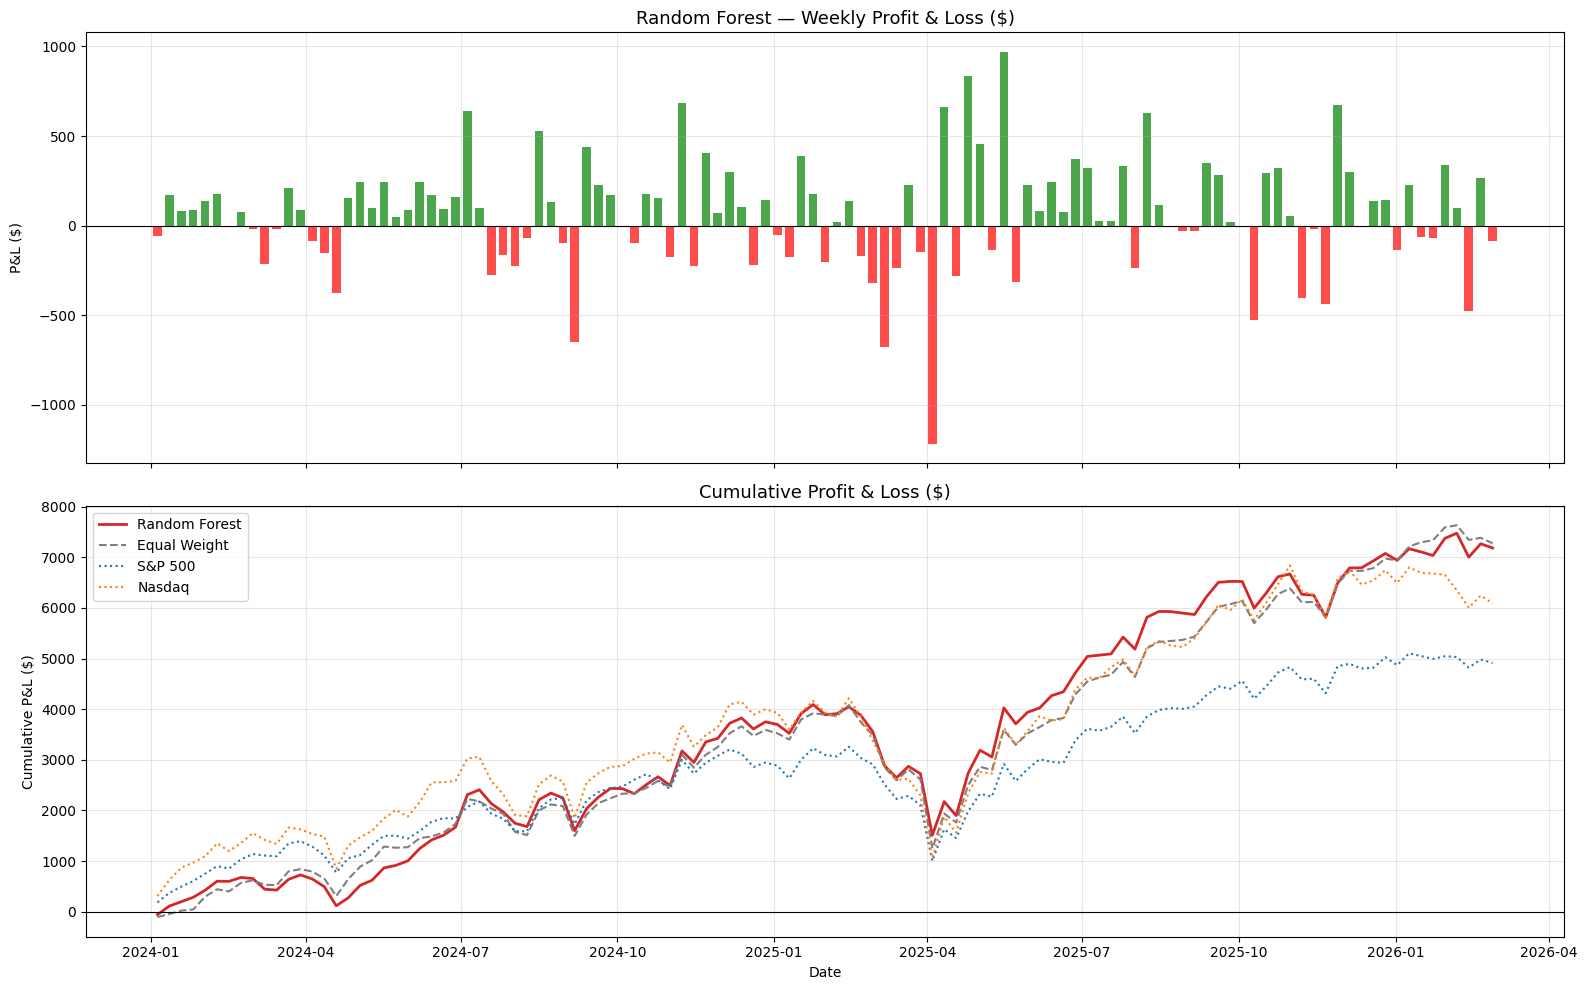

Saved: ../data/results/rf_weekly_pnl.png


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top: Weekly P&L in dollars
ax = axes[0]
colors = ['green' if v >= 0 else 'red' for v in rf_result['Week_PnL']]
ax.bar(rf_result.index, rf_result['Week_PnL'], color=colors, alpha=0.7, width=5)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Random Forest — Weekly Profit & Loss ($)', fontsize=13)
ax.set_ylabel('P&L ($)')
ax.grid(True, alpha=0.3)

# Bottom: Cumulative P&L
ax = axes[1]
ax.plot(rf_result.index,    rf_result['Cumulative_PnL'],    color='#d62728', linewidth=2,   label='Random Forest')
ax.plot(equal_result.index, equal_result['Cumulative_PnL'], color='#7f7f7f', linewidth=1.5, linestyle='--', label='Equal Weight')
for name, res in index_results.items():
    ax.plot(res.index, res['Cumulative_PnL'], linewidth=1.5, linestyle=':', label=name)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Cumulative Profit & Loss ($)', fontsize=13)
ax.set_ylabel('Cumulative P&L ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_weekly_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_weekly_pnl.png')

## 9. Portfolio Value Over Time

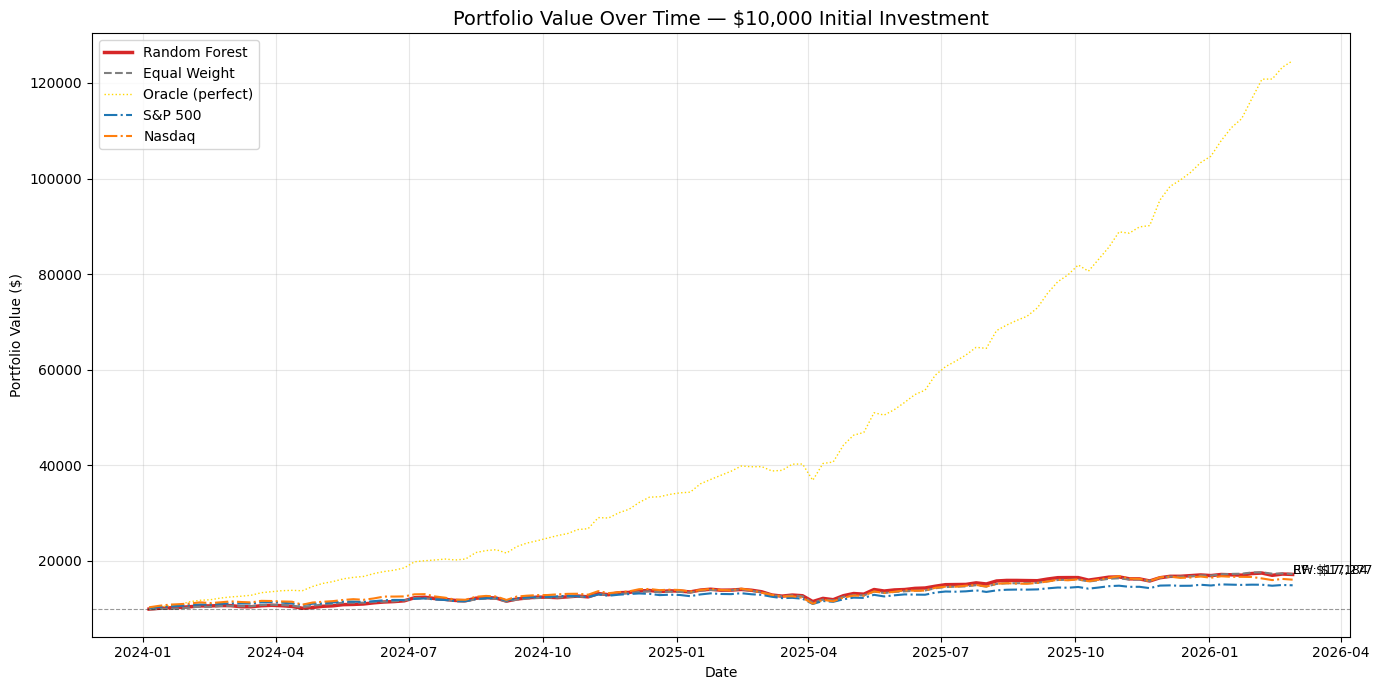

Saved: ../data/results/rf_portfolio_value.png


In [22]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(rf_result.index,     rf_result['Portfolio_Value'],     color='#d62728', linewidth=2.5, label='Random Forest')
ax.plot(equal_result.index,  equal_result['Portfolio_Value'],  color='#7f7f7f', linewidth=1.5, linestyle='--', label='Equal Weight')
ax.plot(oracle_result.index, oracle_result['Portfolio_Value'], color='gold',    linewidth=1,   linestyle=':', label='Oracle (perfect)')
for name, res in index_results.items():
    ax.plot(res.index, res['Portfolio_Value'], linewidth=1.5, linestyle='-.', label=name)

ax.axhline(y=INITIAL_CAPITAL, color='black', linewidth=0.8, linestyle='--', alpha=0.4)

# Annotate final values
for label, res in [('RF', rf_result), ('EW', equal_result)]:
    final = res['Portfolio_Value'].iloc[-1]
    ax.annotate(f'{label}: ${final:,.0f}',
                xy=(res.index[-1], final), fontsize=9, ha='left')

ax.set_title(f'Portfolio Value Over Time — ${INITIAL_CAPITAL:,} Initial Investment', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_portfolio_value.png', dpi=150)
plt.show()
print(f'Saved: {OUT_DIR}/rf_portfolio_value.png')

## 10. Weekly Allocation Heatmap

Shows how portfolio weight shifted across the 15 stocks week by week.

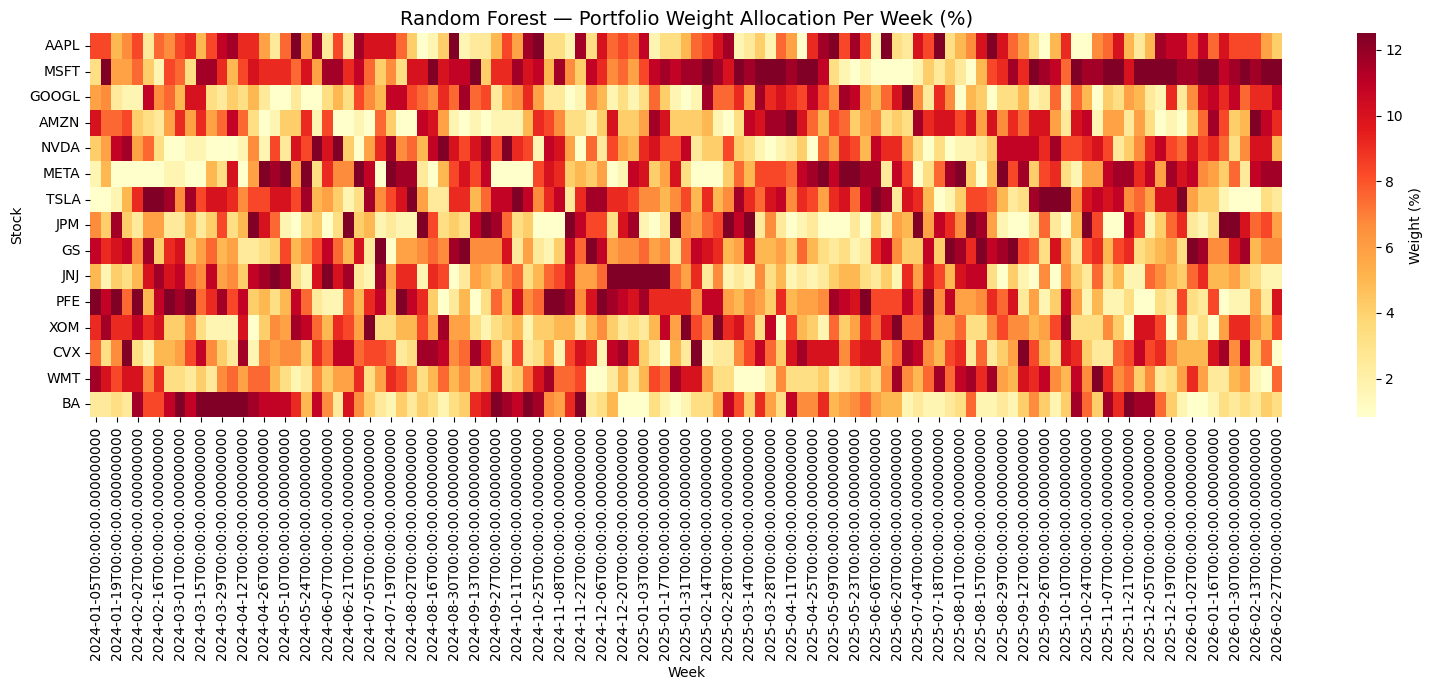

Saved: ../data/results/rf_allocation_heatmap.png


In [23]:
fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(rf_weights.T * 100, cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Weight (%)'}, linewidths=0)
ax.set_title('Random Forest — Portfolio Weight Allocation Per Week (%)', fontsize=14)
ax.set_xlabel('Week')
ax.set_ylabel('Stock')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_allocation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_allocation_heatmap.png')

## 11. Top Pick Performance

Each week the model has a #1 ranked stock — the one it is most confident will go up. How did those picks actually perform?

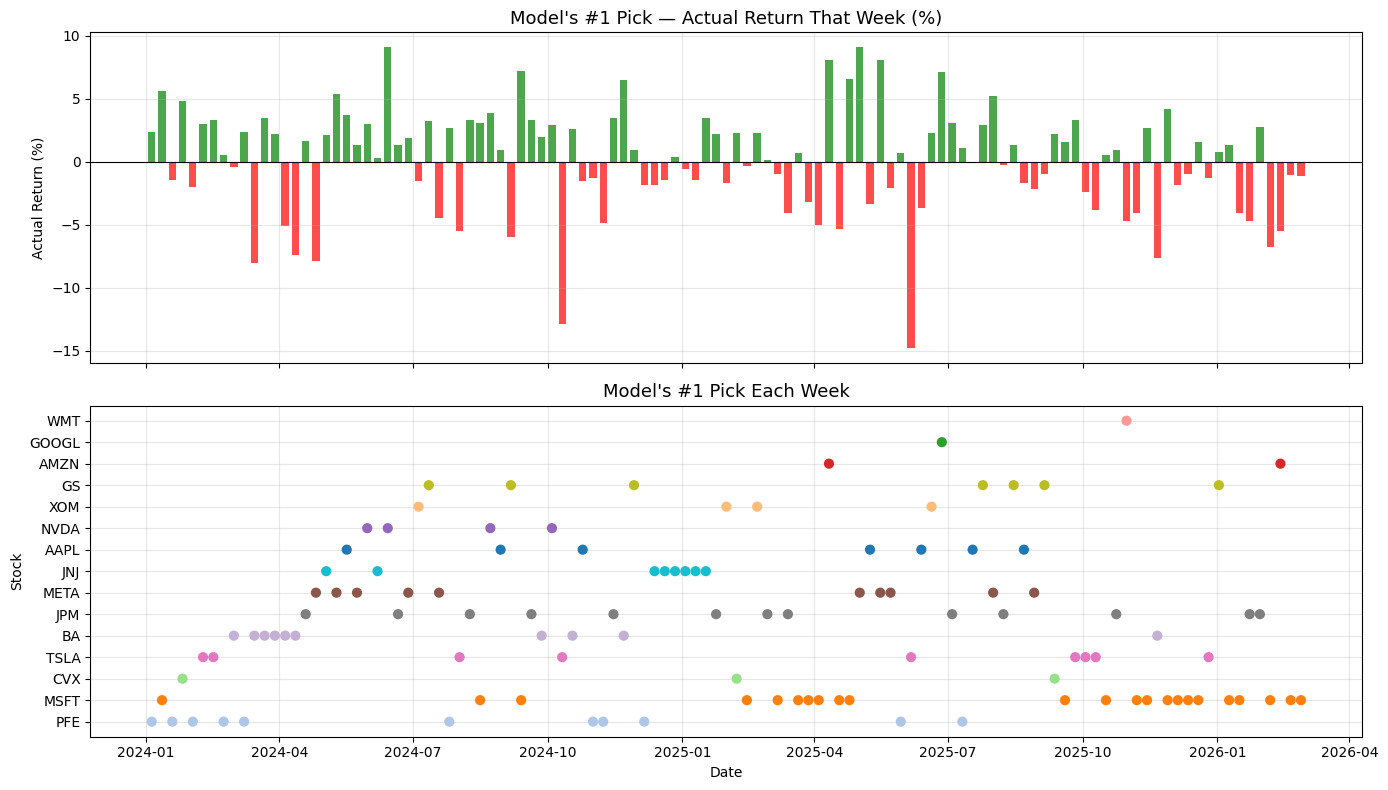

Top pick was positive: 56.6% of weeks (random: 50.0%)

Most frequently picked stock:
Top_Pick
MSFT    23
JPM     13
PFE     11
META    10
BA      10


In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top pick actual return each week
ax = axes[0]
colors = ['green' if v >= 0 else 'red' for v in weekly_table['Top_Pick_Actual_Return']]
ax.bar(weekly_table.index, weekly_table['Top_Pick_Actual_Return'],
       color=colors, alpha=0.7, width=5)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title("Model's #1 Pick — Actual Return That Week (%)", fontsize=13)
ax.set_ylabel('Actual Return (%)')
ax.grid(True, alpha=0.3)

# Which stock was picked each week
ax = axes[1]
tick_labels = weekly_table['Top_Pick']
tick_colors = [COLORS.get(t, '#333333') for t in tick_labels]
ax.scatter(weekly_table.index, weekly_table['Top_Pick'],
           c=tick_colors, s=40, zorder=5)
ax.set_title("Model's #1 Pick Each Week", fontsize=13)
ax.set_ylabel('Stock')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_top_pick.png', dpi=150, bbox_inches='tight')
plt.show()

# Top pick stats
top_pick_positive = (weekly_table['Top_Pick_Actual_Return'] > 0).mean()
print(f'Top pick was positive: {top_pick_positive:.1%} of weeks (random: {1/2:.1%})')
print(f'\nMost frequently picked stock:')
print(weekly_table['Top_Pick'].value_counts().head(5).to_string())

## 12. Performance Metrics

In [25]:
def compute_metrics(result_df, name):
    wr       = result_df['Week_Return']
    n_weeks  = len(wr)
    total_r  = result_df['Cumulative_Return'].iloc[-1] * 100
    ann_r    = ((1 + result_df['Cumulative_Return'].iloc[-1]) ** (52 / n_weeks) - 1) * 100
    sharpe   = (wr.mean() / wr.std()) * np.sqrt(52) if wr.std() > 0 else 0
    cum      = (1 + wr).cumprod()
    peak     = cum.cummax()
    max_dd   = ((cum - peak) / peak).min() * 100
    win_rate = (wr > 0).mean() * 100
    final    = result_df['Portfolio_Value'].iloc[-1]
    return {
        'Strategy':          name,
        'Final Value ($)':   round(final, 2),
        'Total P&L ($)':     round(final - INITIAL_CAPITAL, 2),
        'Total Return (%)':  round(total_r, 2),
        'Annualized (%)':    round(ann_r, 2),
        'Sharpe Ratio':      round(sharpe, 2),
        'Max Drawdown (%)':  round(max_dd, 2),
        'Win Rate (%)':      round(win_rate, 1),
        'Weeks':             n_weeks
    }

rows = [
    compute_metrics(rf_result,     'Random Forest'),
    compute_metrics(equal_result,  'Equal Weight'),
    compute_metrics(oracle_result, 'Oracle (perfect)'),
]
for name, res in index_results.items():
    rows.append(compute_metrics(res, name))

metrics_df = pd.DataFrame(rows).set_index('Strategy')

print('='*70)
print('  BACKTEST PERFORMANCE SUMMARY')
print('='*70)
print(metrics_df.to_string())
metrics_df

  BACKTEST PERFORMANCE SUMMARY
                  Final Value ($)  Total P&L ($)  Total Return (%)  Annualized (%)  Sharpe Ratio  Max Drawdown (%)  Win Rate (%)  Weeks
Strategy                                                                                                                               
Random Forest            17184.02        7184.02             71.84           28.29          1.55            -18.32          60.2    113
Equal Weight             17277.26        7277.26             72.77           28.61          1.63            -20.11          65.5    113
Oracle (perfect)        124647.39      114647.39           1146.47          219.31          6.81             -8.46          90.3    113
S&P 500                  14914.47        4914.47             49.14           20.20          1.35            -17.02          58.4    113
Nasdaq                   16089.50        6089.50             60.89           24.46          1.23            -22.17          57.5    113


,Final Value ($),Total P&L ($),Total Return (%),Annualized (%),Sharpe Ratio,Max Drawdown (%),Win Rate (%),Weeks
Strategy,,,,,,,,
Random Forest,17184.02,7184.02,71.84,28.29,1.55,-18.32,60.2,113
Equal Weight,17277.26,7277.26,72.77,28.61,1.63,-20.11,65.5,113
Oracle (perfect),124647.39,114647.39,1146.47,219.31,6.81,-8.46,90.3,113
S&P 500,14914.47,4914.47,49.14,20.20,1.35,-17.02,58.4,113
Nasdaq,16089.50,6089.50,60.89,24.46,1.23,-22.17,57.5,113


## 13. Metrics Comparison Charts

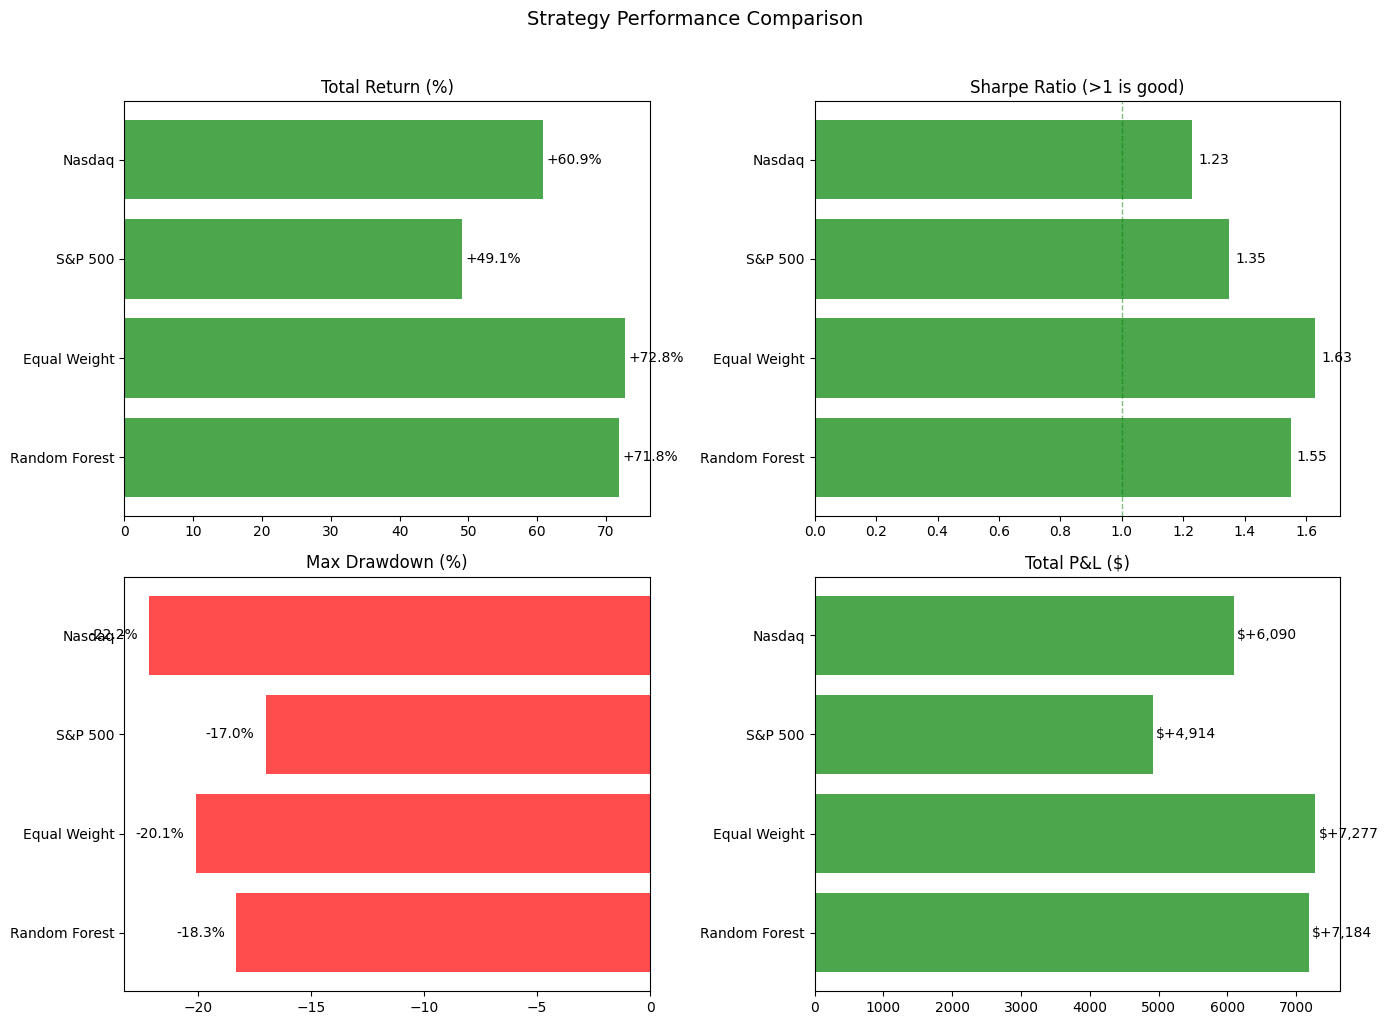

Saved: ../data/results/rf_metrics_comparison.png


In [26]:
compare_df = metrics_df.drop('Oracle (perfect)', errors='ignore')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total Return
ax = axes[0, 0]
vals   = compare_df['Total Return (%)']
colors = ['green' if v > 0 else 'red' for v in vals]
ax.barh(vals.index, vals.values, color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('Total Return (%)', fontsize=12)
for i, v in enumerate(vals):
    ax.text(v + 0.5, i, f'{v:+.1f}%', va='center', fontsize=10)

# Sharpe Ratio
ax = axes[0, 1]
vals   = compare_df['Sharpe Ratio']
colors = ['green' if v > 0.5 else 'orange' if v > 0 else 'red' for v in vals]
ax.barh(vals.index, vals.values, color=colors, alpha=0.7)
ax.axvline(x=1, color='green', linewidth=1, linestyle='--', alpha=0.5)
ax.set_title('Sharpe Ratio (>1 is good)', fontsize=12)
for i, v in enumerate(vals):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

# Max Drawdown
ax = axes[1, 0]
vals   = compare_df['Max Drawdown (%)']
colors = ['red' if v < -15 else 'orange' if v < -10 else 'green' for v in vals]
ax.barh(vals.index, vals.values, color=colors, alpha=0.7)
ax.set_title('Max Drawdown (%)', fontsize=12)
for i, v in enumerate(vals):
    ax.text(v - 0.5, i, f'{v:.1f}%', va='center', ha='right', fontsize=10)

# Total P&L
ax = axes[1, 1]
vals   = compare_df['Total P&L ($)']
colors = ['green' if v > 0 else 'red' for v in vals]
ax.barh(vals.index, vals.values, color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('Total P&L ($)', fontsize=12)
for i, v in enumerate(vals):
    ax.text(v + 50, i, f'${v:+,.0f}', va='center', fontsize=10)

plt.suptitle('Strategy Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/rf_metrics_comparison.png')

## 14. Drawdown Analysis

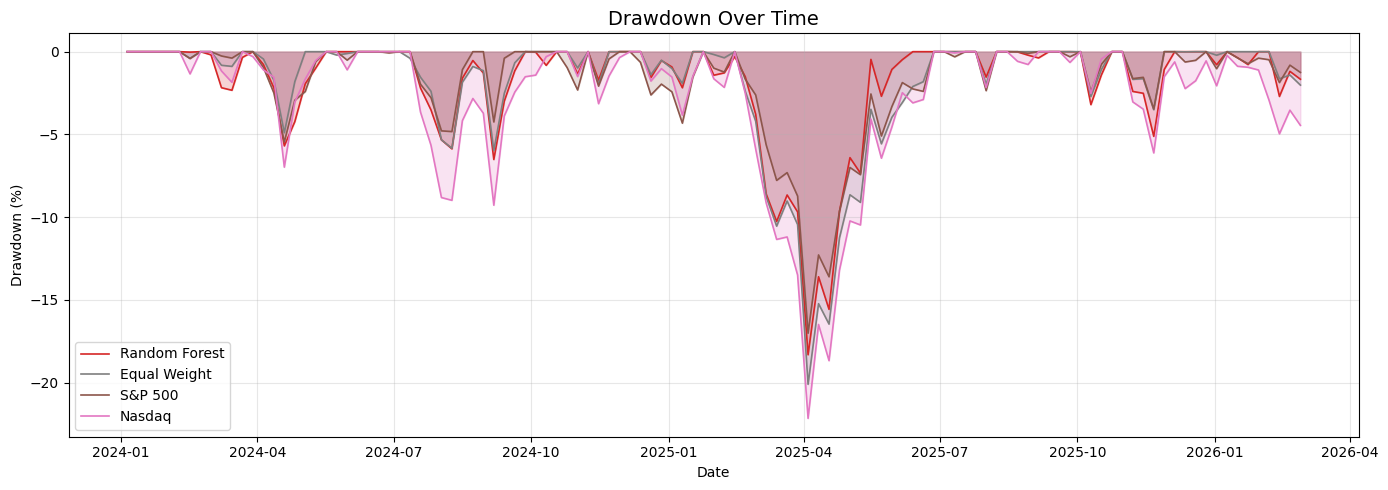

Saved: ../data/results/rf_drawdown.png


In [27]:
fig, ax = plt.subplots(figsize=(14, 5))

strategy_colors = {'Random Forest': '#d62728', 'Equal Weight': '#7f7f7f',
                   'S&P 500': '#8c564b', 'Nasdaq': '#e377c2'}

for name, res in [('Random Forest', rf_result), ('Equal Weight', equal_result)] + list(index_results.items()):
    wr  = res['Week_Return']
    cum = (1 + wr).cumprod()
    dd  = ((cum - cum.cummax()) / cum.cummax()) * 100
    color = strategy_colors.get(name, '#333333')
    ax.fill_between(dd.index, dd.values, 0, alpha=0.2, color=color)
    ax.plot(dd.index, dd.values, label=name, color=color, linewidth=1.2)

ax.set_title('Drawdown Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rf_drawdown.png', dpi=150)
plt.show()
print(f'Saved: {OUT_DIR}/rf_drawdown.png')

## 15. Save All Results

In [28]:
# Full results table
all_returns = pd.DataFrame({
    'Random_Forest': rf_result['Week_Return'],
    'Equal_Weight':  equal_result['Week_Return'],
})
for name, res in index_results.items():
    all_returns[name.replace(' ', '_')] = res['Week_Return']
all_returns.to_csv(f'{OUT_DIR}/rf_backtest_returns.csv')

metrics_df.to_csv(f'{OUT_DIR}/rf_backtest_metrics.csv')
rf_result.to_csv(f'{OUT_DIR}/rf_portfolio_values.csv')

print(f'Saved: {OUT_DIR}/rf_backtest_returns.csv')
print(f'Saved: {OUT_DIR}/rf_backtest_metrics.csv')
print(f'Saved: {OUT_DIR}/rf_portfolio_values.csv')

Saved: ../data/results/rf_backtest_returns.csv
Saved: ../data/results/rf_backtest_metrics.csv
Saved: ../data/results/rf_portfolio_values.csv


## 16. Final P&L Summary

In [29]:
print('='*60)
print(f'  INVESTMENT SIMULATION — ${INITIAL_CAPITAL:,} Starting Capital')
print('='*60)
print(f'  Test Period: {common_dates.min().date()} to {common_dates.max().date()}')
print(f'  Total Weeks: {len(common_dates)}')
print()

for name, m in metrics_df.iterrows():
    emoji = '📈' if m['Total P&L ($)'] > 0 else '📉'
    print(f'  {emoji} {name}')
    print(f'     Final Value:  ${m["Final Value ($)"]:>10,.2f}')
    print(f'     Total P&L:    ${m["Total P&L ($)"]:>+10,.2f}  ({m["Total Return (%)"]:.1f}%)')
    print(f'     Sharpe Ratio: {m["Sharpe Ratio"]:>6.2f}')
    print(f'     Win Rate:     {m["Win Rate (%)"]:.1f}% of weeks profitable')
    print(f'     Max Drawdown: {m["Max Drawdown (%)"]:.1f}%')
    print()

  INVESTMENT SIMULATION — $10,000 Starting Capital
  Test Period: 2024-01-05 to 2026-02-27
  Total Weeks: 113

  📈 Random Forest
     Final Value:  $ 17,184.02
     Total P&L:    $ +7,184.02  (71.8%)
     Sharpe Ratio:   1.55
     Win Rate:     60.2% of weeks profitable
     Max Drawdown: -18.3%

  📈 Equal Weight
     Final Value:  $ 17,277.26
     Total P&L:    $ +7,277.26  (72.8%)
     Sharpe Ratio:   1.63
     Win Rate:     65.5% of weeks profitable
     Max Drawdown: -20.1%

  📈 Oracle (perfect)
     Final Value:  $124,647.39
     Total P&L:    $+114,647.39  (1146.5%)
     Sharpe Ratio:   6.81
     Win Rate:     90.3% of weeks profitable
     Max Drawdown: -8.5%

  📈 S&P 500
     Final Value:  $ 14,914.47
     Total P&L:    $ +4,914.47  (49.1%)
     Sharpe Ratio:   1.35
     Win Rate:     58.4% of weeks profitable
     Max Drawdown: -17.0%

  📈 Nasdaq
     Final Value:  $ 16,089.50
     Total P&L:    $ +6,089.50  (60.9%)
     Sharpe Ratio:   1.23
     Win Rate:     57.5% of weeks p

## 17. Interpretation

### How the Allocation Works
Each Monday, the Random Forest model scores all 15 stocks with a probability of going up (P(Up)). Stocks are ranked 1–15 and portfolio weights are assigned linearly — Rank 1 receives the largest allocation and Rank 15 the smallest. This process repeats every week throughout the test period.

### P&L Framing for an Investor
Starting with $10,000, the week-by-week P&L table (Section 7) shows exactly how much was gained or lost each week by following the model's recommendations. The cumulative P&L chart shows the running total. An investor can compare this directly against simply holding an equal-weight basket of all 15 stocks or a passive index fund.

### Equal Weight Comparison
The equal-weight strategy requires no prediction — it allocates 1/15 to each stock every week. In a broadly bullish market, it benefits from full exposure to all rising stocks without any prediction error penalizing the allocation. The Random Forest adds value when it successfully overweights stocks that outperform and underweights those that underperform relative to the group.

### Why Results May Be Close to Equal Weight
The model's directional accuracy of 48–59% is near random, and its probability outputs cluster narrowly around 0.5. This means the weight differences between the highest and lowest ranked stock each week are small — the allocation is not drastically different from equal weight. In this regime, the model's ranking signal is too weak to consistently generate alpha above a passive benchmark.

### Oracle Benchmark
The oracle strategy always correctly ranks stocks using future knowledge. The gap between Random Forest and Oracle shows the theoretical upside if prediction were perfect — and illustrates how much value better ranking accuracy would add.

### Limitations
- No transaction costs modeled
- Weekly rebalancing assumes execution at closing prices
- Model trained on 2015–2021 data; test period (2024+) may reflect different market dynamics
- With 15 stocks, the linear weighting scheme limits maximum overweight to ~13% above equal weight for the top pick